In [1]:
%pip install python-dotenv langchain-groq langgraph
from langchain_core.messages import HumanMessage, ToolMessage
from langchain.tools import tool
from langchain_core.prompts import ChatPromptTemplate
from dotenv import load_dotenv
import os

load_dotenv()

if os.getenv("GROQ_API_KEY"):
    print("Groq API key is set.")
else:
    raise ValueError("Groq API key is not set.")
from langchain_groq import ChatGroq

model = ChatGroq(
    model="llama-3.3-70b-versatile"
)
model
model.invoke("tell me what should be do if our gf is angrey").content

Note: you may need to restart the kernel to use updated packages.


c:\Users\puroh\Desktop\langgraph-tutoril\.venv\Scripts\python.exe: No module named pip


Groq API key is set.


'A very common and delicate situation! If your girlfriend is angry, here are some steps you can take to help calm her down and resolve the issue:\n\n1. **Stay calm**: It\'s essential to remain calm and composed, even if your girlfriend is upset. Avoid getting defensive or matching her level of anger, as this can escalate the situation.\n2. **Listen actively**: Allow her to express her feelings and concerns without interrupting. Listen attentively to what she\'s saying, and try to understand her perspective.\n3. **Acknowledge her emotions**: Validate her feelings by acknowledging that you understand she\'s upset and that her emotions are real. You can say something like, "I can see that you\'re really upset, and I\'m sorry you\'re feeling that way."\n4. **Give her space (if needed)**: If your girlfriend needs some time to calm down, give her space. Respect her boundaries and don\'t push her to talk if she\'s not ready.\n5. **Apologize (if you\'re at fault)**: If you\'ve done something t

In [2]:
from typing import TypedDict, List, Annotated
from langgraph.graph.message import add_messages

class graph_schema(TypedDict):
    messages: Annotated[List, add_messages]

In [4]:
def welcome(schema:graph_schema) -> graph_schema:

    curr_message = schema['messages']

    response = model.invoke(curr_message).content

    schema['messages'] = f"Your message was {curr_message}. Here's my response:  {response}"

    return schema

In [5]:

from langgraph.graph import StateGraph, START, END

graph = StateGraph(graph_schema)

# Adding Nodes
graph.add_node("welcome", welcome)

# Adding Edges
graph.add_edge(START, "welcome")
graph.add_edge("welcome", END)

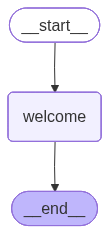

In [6]:
from IPython.display import Image, display
from langgraph.checkpoint.memory import InMemorySaver  

checkpoint = InMemorySaver()

memory_graph = graph.compile(checkpointer=checkpoint)

# You could see the errors with the below command
Image(memory_graph.get_graph().draw_mermaid_png())

In [10]:

response = memory_graph.invoke(
    {"messages":"What is my namee?"},
    {'configurable':{'thread_id': 'anshlamba'}}
)

for message in response['messages']:
    message.pretty_print()

================================ Human Message =================================

What is my name?
================================ Human Message =================================

Your message was [HumanMessage(content='What is my name?', additional_kwargs={}, response_metadata={}, id='3b183146-283c-4a87-843b-9dd0307f88b7')]. Here's my response:  I don't know your name. I'm a large language model, I don't have any information about you, including your name. I'm here to help answer your questions and provide information, but I don't have any personal data about you. If you'd like to share your name with me, I'd be happy to chat with you and use it in our conversation!
================================ Human Message =================================

What is rizwan randi?
================================ Human Message =================================

Your message was [HumanMessage(content='What is my name?', additional_kwargs={}, response_metadata={}, id='3b183146-283c-4a87-843b-9dd030